Types of RNN Architecture :
There are 3 types of RNN architecture which are :

One to Many
Many to One
Many to Many
1. One to Many :
In recurrent neural networks (RNNs), a “one-to-many” architecture represents a scenario where the network receives a single input but generates a sequence of outputs. This is the opposite of a many-to-one RNN.

Here’s a breakdown of how it works:

Single Input: The RNN takes in a single piece of information as input. This could be an image, a musical note, a short sentence, or any data point that serves as a starting point for the network.
Multiple Outputs: The RNN processes the input and generates a sequence of outputs over time. This sequence can vary in length depending on the specific task.
Here are some common applications of one to many RNNs:

Image Captioning: Based on a single image input, the RNN generates a sentence or paragraph describing the image content (multiple outputs).
Music Generation: The RNN receives a single starting note or short melody as input and produces a sequence of musical notes forming a complete piece (multiple outputs).
2. Many to One :
In recurrent neural networks (RNNs), a “many-to-one” architecture refers to a specific type of RNN where the network processes a sequence of inputs but produces a single output.

Here’s a breakdown of how it works:

Many Inputs: The RNN takes in a sequence of data points over time. This sequence could be words in a sentence, sensor readings over a period, or financial data points for multiple days.
Single Output: After processing the entire sequence, the RNN generates a single output value. This output could be a classification (positive/negative sentiment), a prediction (next value in the time series), or a summary of the information in the sequence.
Here are some common applications of many-to-one RNNs:

Sentiment Analysis: Given a sentence or review text (sequence of words), classify its overall sentiment (positive, negative, or neutral) as the single output.
Spam Detection: Analyze an email’s content (sequence of words) to determine if it’s spam (single output).
3. Many to Many :
In recurrent neural networks (RNNs), a “many-to-many” architecture describes a scenario where the network processes a sequence of inputs and generates a corresponding sequence of outputs. This means both the input and output have multiple elements processed over time steps.


Multiple Inputs: The RNN takes in a sequence of data points, similar to many-to-one RNNs. This sequence could be words in a sentence, sensor readings, or financial data points.
Multiple Outputs: The RNN generates a new sequence of data points, with a length that may or may not be the same as the input sequence.
There are two main categories of many-to-many RNNs:

Fixed Length: In this case, the number of elements in the output sequence is the same as the number of elements in the input sequence. A common application is named entity recognition (NER), where the network identifies and classifies each word in a sentence (input sequence) as a specific entity type (i.e. parts of speech) (output sequence).
Variable Length: Here, the output sequence can have a different length than the input sequence. This is particularly useful for tasks like machine translation, where the source sentence (input sequence) in one language might be translated into a longer or shorter sentence (output sequence) in another language.
Common Applications of Many-to-Many RNNs:

Machine Translation: Translate text from one language to another (e.g., English to French).
Video Captioning: Generate captions describing the content of a video (sequence of video frames as input, sequence of words as output).
Text Summarization: Summarize a long document into a shorter version with key points (sequence of sentences as input, shorter sequence of sentences as output).
Network Architectures for Many-to-Many RNNs:

A common approach for many-to-many RNNs is the encoder-decoder architecture. Here, the network is divided into two parts:

Encoder: This part processes the input sequence and captures its meaning in a hidden representation.
Decoder: This part takes the hidden representation from the encoder and generates the output sequence element by element.
Important note :- One to One architecture is not a type of RNN because a one-to-one situation involves a single input and a single output, with no concept of sequence. However, for this specific task (single input to single output), both Convolutional Neural Networks (CNNs, for example image classification) and Artificial Neural Networks (ANNs) can be suitable candidates, depending on the nature of the input data.

Backpropagation in RNNs :
Backpropagation in RNNs, also known as Backpropagation Through Time (BPTT), is a crucial technique for training these networks. It allows them to learn and improve their performance on tasks involving sequential data.

Let’s take an example to understand the back propagation in many to one RNNs architecture :

1. Forward Pass:
The RNN processes a sequence of inputs one step at a time. At each step, the current input and the previous hidden state are fed into the network’s activation function to generate a new hidden state and an output.
Press enter or click to view image in full size
2. Error Calculation:
After processing the entire sequence, the difference (error) between the network’s final output and the desired output for the sequence is calculated.
3. Weight Update:
Using the gradients, the weights in the actual RNN are adjusted in a way that will minimize the error in future predictions. Weights that significantly contributed to the error are adjusted more than those with minimal influence.

In [1]:
import warnings
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

import re
import nltk
nltk.download('all')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
lemm = WordNetLemmatizer()

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

In [3]:
data = pd.read_csv("/content/Clothing-Review.csv")
data.head()
data = data[data['Class Name'].isnull() == False]

/tmp/ipykernel_792/1574157729.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Class Name', palette='rainbow')


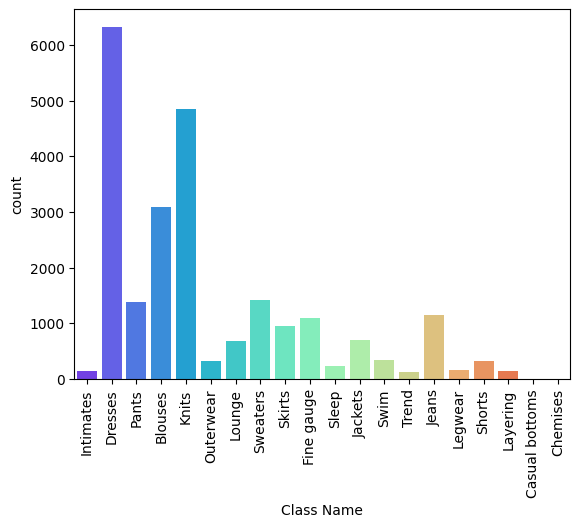

In [4]:
sns.countplot(data=data, x='Class Name', palette='rainbow')
plt.xticks(rotation=90)
plt.show()

/tmp/ipykernel_792/1673799759.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Rating',palette="deep")
/tmp/ipykernel_792/1673799759.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="Recommended IND", palette="deep")


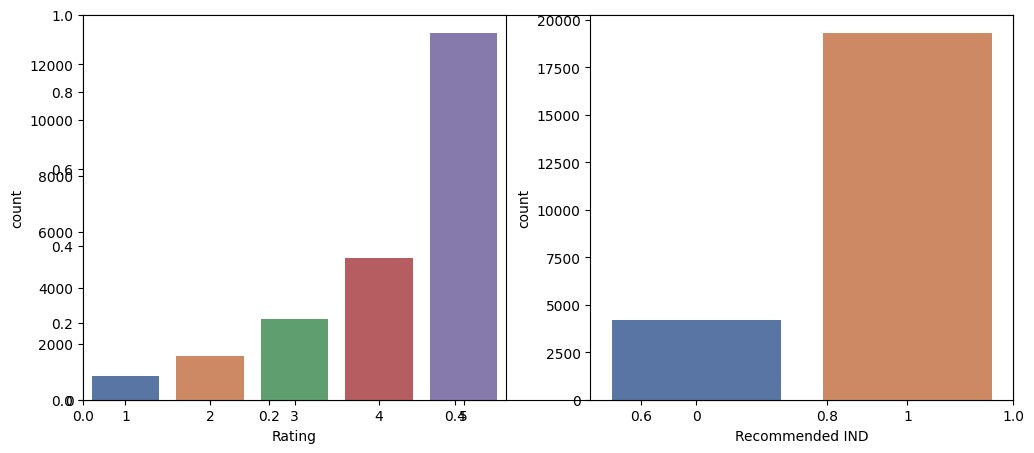

In [5]:
plt.subplots(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=data, x='Rating',palette="deep")

plt.subplot(1, 2, 2)
sns.countplot(data=data, x="Recommended IND", palette="deep")
plt.show()

In [6]:
fig = px.histogram(data, marginal='box',
                   x="Age", title="Age Group",
                   color="Recommended IND",
                   nbins=65-18,
                   color_discrete_sequence=['green', 'red'])
fig.update_layout(bargap=0.2)

In [7]:
fig = px.histogram(data,
                   x="Age",
                   marginal='box',
                   title="Age Group",
                   color="Rating",
                   nbins=65-18,
                   color_discrete_sequence
                   =['black', 'green', 'blue', 'red', 'yellow'])
fig.update_layout(bargap=0.2)

In [8]:
def filter_score(rating):
    return int(rating > 3)

features = ['Class Name', 'Title', 'Review Text']

X = data[features]
y = data['Rating']
y = y.apply(filter_score)

In [9]:
def toLower(data):
    if isinstance(data, float):
        return '<UNK>'
    else:
        return data.lower()

stop_words = stopwords.words("english")

In [10]:
def remove_stopwords(text):
    no_stop = []
    for word in text.split(' '):
        if word not in stop_words:
            no_stop.append(word)
    return " ".join(no_stop)

In [11]:
def remove_punctuation_func(text):
    return re.sub(r'[^a-zA-Z0-9]', ' ', text)

X['Title'] = X['Title'].apply(toLower)
X['Review Text'] = X['Review Text'].apply(toLower)

X['Title'] = X['Title'].apply(remove_stopwords)
X['Review Text'] = X['Review Text'].apply(remove_stopwords)

X['Title'] = X['Title'].apply(lambda x: lemm.lemmatize(x))
X['Review Text'] = X['Review Text'].apply(lambda x: lemm.lemmatize(x))

X['Title'] = X['Title'].apply(remove_punctuation_func)
X['Review Text'] = X['Review Text'].apply(remove_punctuation_func)

X['Text'] = list(X['Title']+X['Review Text']+X['Class Name'])


X_train, X_test, y_train, y_test = train_test_split(
    X['Text'], y, test_size=0.25, random_state=42)

/tmp/ipykernel_792/274947715.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_792/274947715.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_792/274947715.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_792/274947

In [12]:
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

Padding is used to make all text sequences the same length before feeding them into the neural network. Extra zeros are added to shorter sequences, while longer sequences can be truncated if needed.

In [13]:
train_seq = tokenizer.texts_to_sequences(X_train)
test_seq = tokenizer.texts_to_sequences(X_test)

train_pad = pad_sequences(train_seq,
                          maxlen=40,
                          truncating="post",
                          padding="post")
test_pad = pad_sequences(test_seq,
                         maxlen=40,
                         truncating="post",
                         padding="post")

In [14]:
model=keras.models.Sequential()
model.add(keras.layers.Embedding(input_dim=10000,output_dim=128,input_length=40))
model.add(keras.layers.SimpleRNN(64,return_sequences=True))
model.add(keras.layers.SimpleRNN(64))
model.add(keras.layers.Dense(128,activation="relu"))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(1,activation="sigmoid"))
model.build(input_shape=(None,40))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 40, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 40, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,309,057 (4.99 MB)

 Trainable params: 1,309,057 (4.99 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(loss="binary_crossentropy",optimizer="adam",
              metrics=["accuracy"])
history = model.fit(train_pad,
                    y_train,
                    epochs=5)

Epoch 1/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8244 - loss: 0.4200
Epoch 2/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.8863 - loss: 0.2876
Epoch 3/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8557 - loss: 0.3887
Epoch 4/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8358 - loss: 0.4470
Epoch 5/5
551/551 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.8377 - loss: 0.4379
